In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from PIL import Image
from IPython.display import display
import torchvision.transforms.functional as F

%load_ext autoreload 
%autoreload 2
    
torch.hub.set_dir("../model_cache/torch/hub")
import sys
sys.path.append("/mnt/home/mizrahiulysse/ElasticDino")
from elasticdino.model.elasticdino import ElasticDino

def get_edino():
    edino = ElasticDino.from_pretrained("/mnt/home/mizrahiulysse/pixelvit-32-L.pth", "elasticdino-32-L", dino_repo="/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main")
    edino.eval()
    edino.requires_grad_ = False
    return edino

edino = get_edino().cuda()
# edino = torch.compile(get_edino().cuda())

/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/mnt/home/mizrahiulysse/model_cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


In [2]:
from elasticdino.data.imagenet import load_imagenet
imagenet = load_imagenet("/mnt/home/mizrahiulysse/datasets/imagenet-1k-256/imagenet/train", 1, image_size=256)

Loading imagenet


/mnt/projects/conda-envs/dgxenv-2025-03-03-16-47-41-x2481-centos9-py310-pt251cf/lib/python3.10/site-packages/datasets/table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


Imagenet loaded


In [3]:
from transformers import SiglipProcessor, AutoModel

siglip_path = "/mnt/home/mizrahiulysse/model_cache/models--google--siglip-base-patch16-224/snapshots/7fd15f0689c79d79e38b1c2e2e2370a7bf2761ed"

siglip = AutoModel.from_pretrained(siglip_path).cuda()
siglip_processor = SiglipProcessor.from_pretrained(siglip_path)



In [4]:
def get_image_features(images):
    inputs = siglip_processor(images=images, padding="max_length", return_tensors="pt")
    for k in inputs:
        inputs[k] = inputs[k].cuda()
    return siglip.get_image_features(**inputs)

import random

def random_crop_and_paste(x, y):
  # x and y: [B, C, H, W]
  # Make a copy of x to paste onto
  x_out = x.clone()
  B, C, H_x, W_x = x.shape
  _, _, H_y, W_y = y.shape

  min_crop_height = int(H_x / 4)
  max_crop_height = int(5 * H_x / 6)
  min_crop_width = int(W_x / 4)
  max_crop_width = int(5 * W_x / 6)
  mask = torch.zeros_like(x)
  patches = []
  for i in range(B):
    # Determine random crop size for y[i]
    crop_h = random.randint(min_crop_height, min(max_crop_height, H_y))
    crop_w = random.randint(min_crop_width, min(max_crop_width, W_y))
    
    # Random top-left coordinates for crop in y[i]
    top_y = random.randint(0, H_y - crop_h)
    left_y = random.randint(0, W_y - crop_w)
    
    # Crop the patch from y[i]
    patch = y[i, :, top_y:top_y+crop_h, left_y:left_y+crop_w]
    
    # Determine a random valid position in x[i] where the patch fits
    top_x = random.randint(0, H_x - crop_h)
    left_x = random.randint(0, W_x - crop_w)
    
    # Paste the patch onto x_out[i]
    x_out[i, :, top_x:top_x+crop_h, left_x:left_x+crop_w] = patch
    mask[i, :, top_x+4:top_x+crop_h-4, left_x+4:left_x+crop_w-4] = 1
    patches.append(patch)
  
  return x_out, patches, mask

def sample_image_points(edino_features, pasted, mask, proportion):
    B, F, H, W = edino_features.shape
    n_samples = int(proportion * H * W)
    edino_features = edino_features.reshape((B, F, -1))
    pasted = pasted.reshape((B, 3, -1))
    mask = mask.reshape((B, 1, -1))

    indices = torch.stack([torch.randperm(H * W)[:n_samples] for _ in range(B)], dim=0).to(pasted.device)
    indices_expanded = indices.unsqueeze(1).expand(B, F, n_samples)
  
    edino_features = torch.gather(edino_features, dim=2, index=indices.unsqueeze(1).expand(B, F, n_samples)).transpose(1, 2) # don't reshape yet
    pasted = torch.gather(pasted, dim=2, index=indices.unsqueeze(1).expand(B, 3, n_samples))
    pasted = pasted.transpose(1, 2).reshape((B * n_samples, 3))
    mask = torch.gather(mask, dim=2, index=indices.unsqueeze(1))
    mask = mask.flatten()
    return edino_features, pasted, mask, indices


class ResidualFC(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, n_features),
            nn.InstanceNorm1d(n_features),
            nn.ReLU(True),
        )

    def forward(self, x):
        return x + self.layers(x)

class FC(nn.Module):
    def __init__(self, fin, out):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(fin, out),
            nn.InstanceNorm1d(out),
            nn.ReLU(True),
        )

    def forward(self, x):
        return self.layers(x)

class Model(nn.Module):
    def __init__(self, features_in, n_features=2048):
        super().__init__()
        self.layers = nn.Sequential(
            FC(features_in, n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            FC(n_features, n_features // 4),
            ResidualFC(n_features // 4),
            ResidualFC(n_features // 4),
            FC(n_features // 4, n_features // 8),
            ResidualFC(n_features // 8),
            ResidualFC(n_features // 8),
            FC(n_features // 8, n_features // 16),
            ResidualFC(n_features // 16),
            ResidualFC(n_features // 16),
            nn.Linear(n_features // 16, 1),
        )

    def forward(self, x):
        return self.layers(x)

        
class EncoderModel(nn.Module):
    def __init__(self, features_in, n_features=2048):
        super().__init__()
        self.edino_encoder = nn.Sequential(
            FC(1024, n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            nn.Linear(n_features, n_features),
            
        )

        self.siglip_encoder = nn.Sequential(
            FC(768, n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            ResidualFC(n_features),
            nn.Linear(n_features, n_features),
        )

    def forward(self, edino_features, siglip_features):
        edino_features = self.edino_encoder(edino_features)
        edino_features = edino_features / edino_features.norm(dim=1, keepdim=True)
        siglip_features = self.siglip_encoder(siglip_features)
        siglip_features = siglip_features / siglip_features.norm(dim=1, keepdim=True)
        res = 8 * (edino_features * siglip_features).sum(dim=1)
        return res
        
        
torch.no_grad
def make_saliency_map(model, image, text):
    C, H, W = image.shape
    features = edino(image.unsqueeze(0)).squeeze().reshape((1024, H * W)).transpose(0, 1)
    objects_features = siglip.get_text_features(siglip_processor(text=[text])["input_ids"].cuda())
    objects_features = objects_features.repeat(features.shape[0], 1)
    # features = torch.cat([features, objects_features], dim=1)
    res = torch.sigmoid(model(features, objects_features)).reshape((H, W))
    display(F.to_pil_image(res))
    

def train_siglip(debug_interval=100, batch_size=8, max_iterations=None):
    n = 0
    total_features = 1024 + 768
    model = EncoderModel(total_features).cuda()
    import bitsandbytes
    optimizer = bitsandbytes.optim.AdamW8bit(
        [{"params": model.parameters(), "lr": 1e-3}], eps=1e-5, weight_decay=0.0)
    scaler = torch.amp.GradScaler()
    running_loss = None
    for epoch in range(10):
        for images in load_imagenet("/mnt/home/mizrahiulysse/datasets/imagenet-1k-256/imagenet/train", batch_size, image_size=128):
            n+=1
            if max_iterations is not None and n > max_iterations:
                return
            with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                with torch.no_grad():
                    images = images.cuda()
                    backgrounds = images[:batch_size // 2]
                    objects = images[batch_size // 2:]
                    pasted, patches, mask = random_crop_and_paste(backgrounds, objects)
                    objects_features = torch.stack([get_image_features(patch) for patch in patches])
                    features = edino(pasted)
                    features, pasted, mask, indices = sample_image_points(features, pasted, mask, proportion=0.03125)
                    objects_features = objects_features.repeat(1, features.shape[1], 1).reshape((-1, 768))
                    # objects_features = objects_features.repeat(1, features.shape[1], 1)
                    # features = torch.cat([features, objects_features], dim=2).reshape((-1, total_features))
                    features = features.reshape((-1, 1024))
                    # del objects_features
                predicted = model(features, objects_features).squeeze()
                # predicted = model(features).squeeze()
                loss = nn.BCEWithLogitsLoss()(predicted, mask)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
    
            optimizer.zero_grad()
            if running_loss is None:
              running_loss = loss.detach()
            else:
              running_loss = 0.98 * running_loss + 0.02 * loss.detach()  
            if n % debug_interval == 0:
                print(n, running_loss.item())
                make_saliency_map(model, F.pil_to_tensor(Image.open("dog.jpeg").convert("RGB").resize((128, 128))).cuda() / 255.0, "grass")
                make_saliency_map(model, F.pil_to_tensor(Image.open("person.jpeg").convert("RGB").resize((128, 128))).cuda() / 255.0, "hair")
                make_saliency_map(model, F.pil_to_tensor(Image.open("car.jpeg").convert("RGB").resize((128, 128))).cuda() / 255.0, "window")
                
            
            
            del images
            del backgrounds
            del pasted
            del objects
            del features
            del predicted
            del loss

        

# train_siglip(debug_interval=250)

4900 2.094029188156128


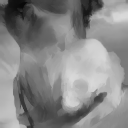

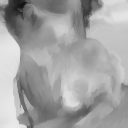

5000 2.0878939628601074


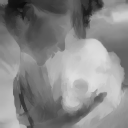

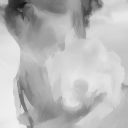

5100 2.0514214038848877


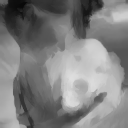

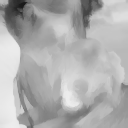

5200 2.0413708686828613


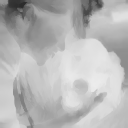

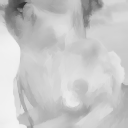

5300 2.0577352046966553


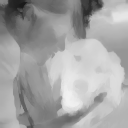

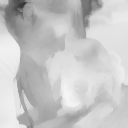

5400 2.0157852172851562


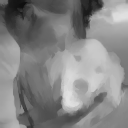

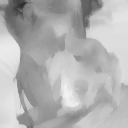

5500 2.0373694896698


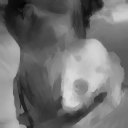

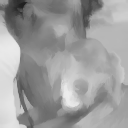

5600 2.0496826171875


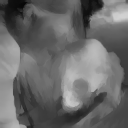

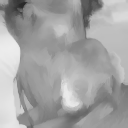

5700 2.0188257694244385


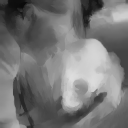

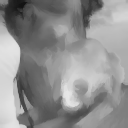

5800 2.009716749191284


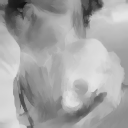

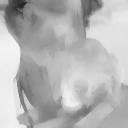

5900 2.0149080753326416


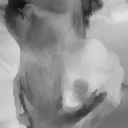

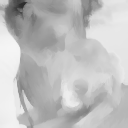

6000 2.062570095062256


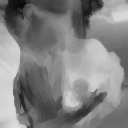

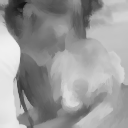

6100 2.0269768238067627


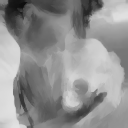

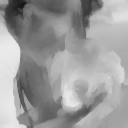

6200 2.052309274673462


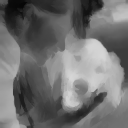

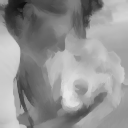

6300 2.0620665550231934


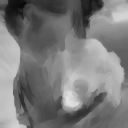

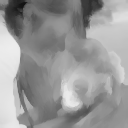

6400 2.0379998683929443


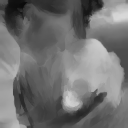

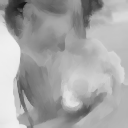

6500 1.9821934700012207


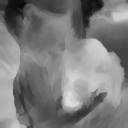

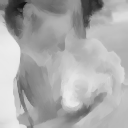

6600 1.9947035312652588


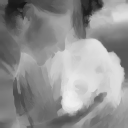

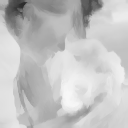

6700 2.051286458969116


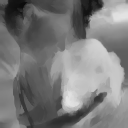

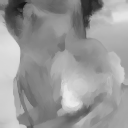

6800 2.00600266456604


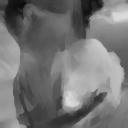

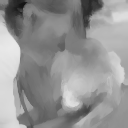

6900 1.9809664487838745


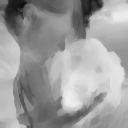

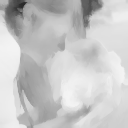

7000 1.9759340286254883


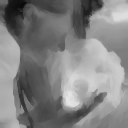

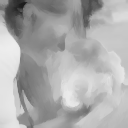

7100 1.9624673128128052


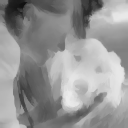

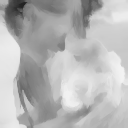

7200 1.9911514520645142


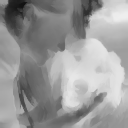

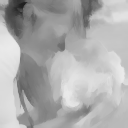

7300 1.9813750982284546


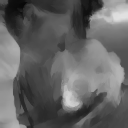

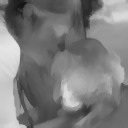

7400 2.0233407020568848


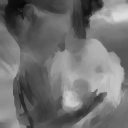

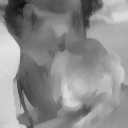

7500 1.9901925325393677


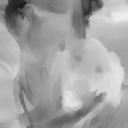

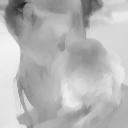

7600 1.9716086387634277


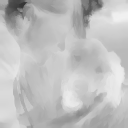

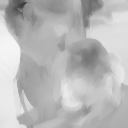

7700 1.9523723125457764


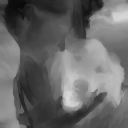

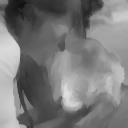

7800 1.9210971593856812


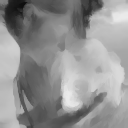

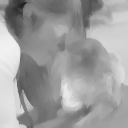

7900 1.9433940649032593


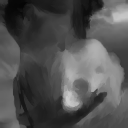

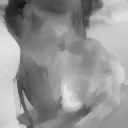

8000 1.9399619102478027


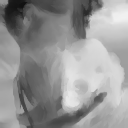

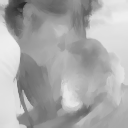

8100 1.9237496852874756


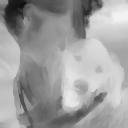

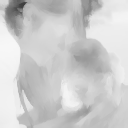

8200 1.9188175201416016


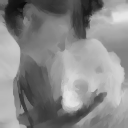

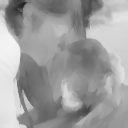

8300 1.9464808702468872


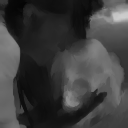

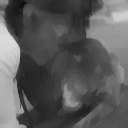

8400 1.9359230995178223


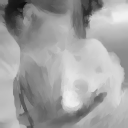

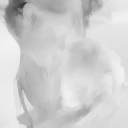

8500 1.8991587162017822


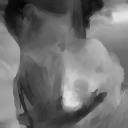

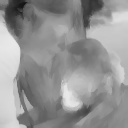

8600 1.9041852951049805


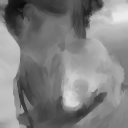

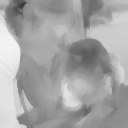

8700 1.915325403213501


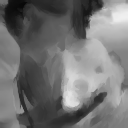

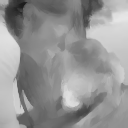

8800 1.9063149690628052


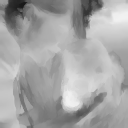

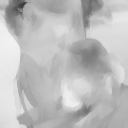

8900 1.9094432592391968


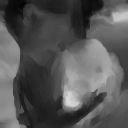

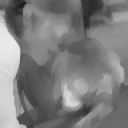

9000 1.924865484237671


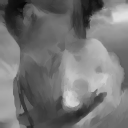

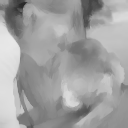

9100 1.915647268295288


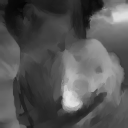

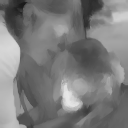

9200 1.930769920349121


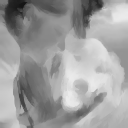

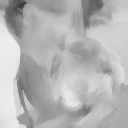

9300 1.889996886253357


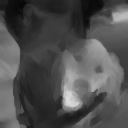

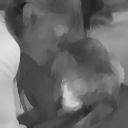

9400 1.905491590499878


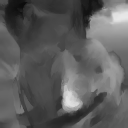

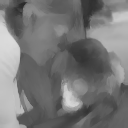

9500 1.907945156097412


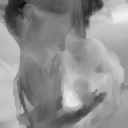

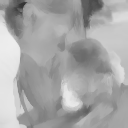

9600 1.869862675666809


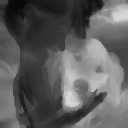

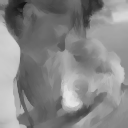

9700 1.9035990238189697


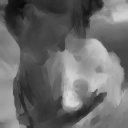

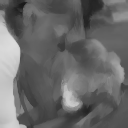

9800 1.9081095457077026


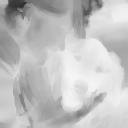

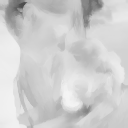

9900 1.90028977394104


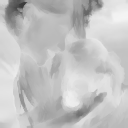

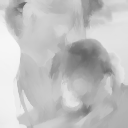

10000 1.8905340433120728


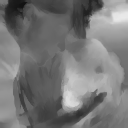

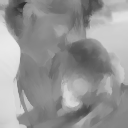

10100 1.9059350490570068


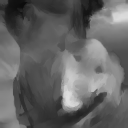

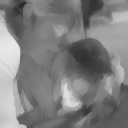

10200 1.865700602531433


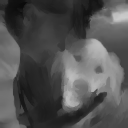

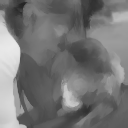

10300 1.8359819650650024


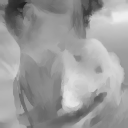

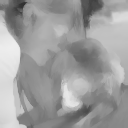

10400 1.8639318943023682


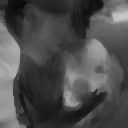

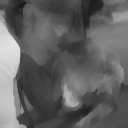

10500 1.8333890438079834


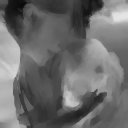

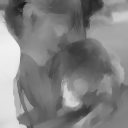

10600 1.840480089187622


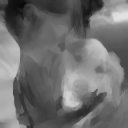

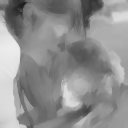

10700 1.848962426185608


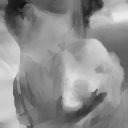

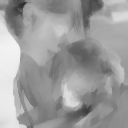

10800 1.8705631494522095


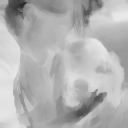

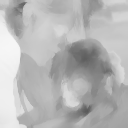

10900 1.8490970134735107


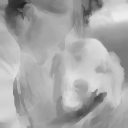

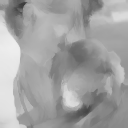

11000 1.832797884941101


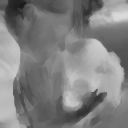

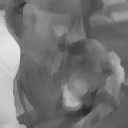

11100 1.8111977577209473


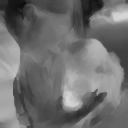

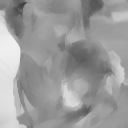

11200 1.8119179010391235


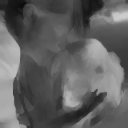

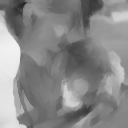

11300 1.8380435705184937


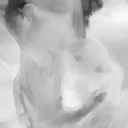

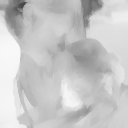

11400 1.8059136867523193


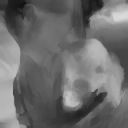

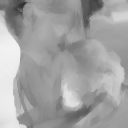

11500 1.8263256549835205


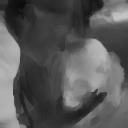

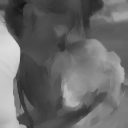

11600 1.8599594831466675


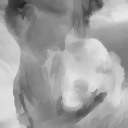

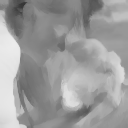

11700 1.859043002128601


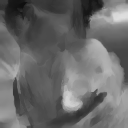

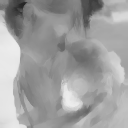

11800 1.8650689125061035


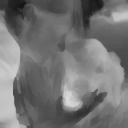

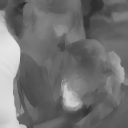

11900 1.8400650024414062


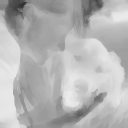

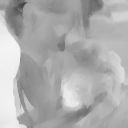

12000 1.8402260541915894


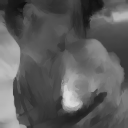

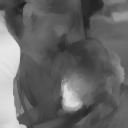

12100 1.805417776107788


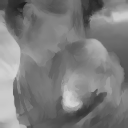

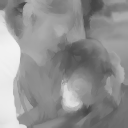

12200 1.803351640701294


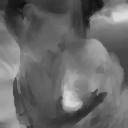

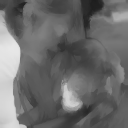

12300 1.782251238822937


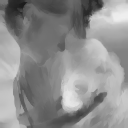

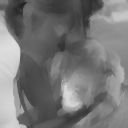

12400 1.7976012229919434


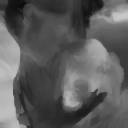

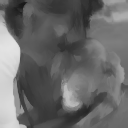

12500 1.7979116439819336


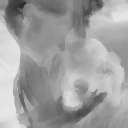

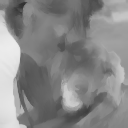

12600 1.8060636520385742


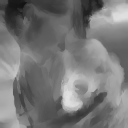

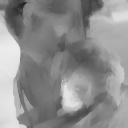

In [ ]:

        
class EncoderModelContrastive(nn.Module):
    def __init__(self, n_features=2048, n_encoder_layers=5):
        super().__init__()
        self.edino_encoder = nn.Sequential(
            FC(1024, n_features),
            # *[ResidualFC(n_features) for _ in range(n_encoder_layers)],
            # nn.Linear(n_features, n_features),
            # nn.ReLU(),
            # nn.Linear(n_features, n_features),
            # nn.ReLU(),
        )

        self.siglip_encoder = nn.Sequential(
            FC(768, n_features),
            *[ResidualFC(n_features) for _ in range(n_encoder_layers)],
            nn.Linear(n_features, n_features),
            nn.InstanceNorm1d(n_features)
            # nn.ReLU(),
            # nn.Linear(n_features, n_features),
            # nn.ReLU(),
        )

    def forward(self, edino_features, siglip_features):
        edino_features = self.edino_encoder(edino_features)
        edino_features = edino_features / edino_features.norm(dim=-1, keepdim=True)
        siglip_features = self.siglip_encoder(siglip_features)
        siglip_features = siglip_features / siglip_features.norm(dim=-1, keepdim=True)
        return edino_features, siglip_features

TEMPERATURE = 0.1

def contrastive_loss(edino_features, siglip_features):
    #edino: B x N x F, siglip B x F
    B, N, _ = edino_features.shape
    logits = torch.einsum("bni,ci->nbc", edino_features, siglip_features) / TEMPERATURE # N x B x B
    # print(logits)
    labels = torch.arange(B, device=edino_features.device).long().unsqueeze(0).repeat((N, 1)) # N x B
    return (
        nn.functional.cross_entropy(logits, labels) +
        nn.functional.cross_entropy(logits.transpose(1, 2), labels)
    ) / 2
    
torch.no_grad
def make_saliency_map_contrastive(model, image, text):
    C, H, W = image.shape
    N = H * W
    edino_features = edino(image.unsqueeze(0)).squeeze().reshape((1024, N)).transpose(0, 1)
    
    siglip_features = siglip.get_text_features(siglip_processor(text=[text])["input_ids"].cuda())
    edino_features, siglip_features = model(edino_features, siglip_features)
    
    edino_features = edino_features.reshape((N, edino_features.shape[-1]))
    siglip_features = siglip_features.squeeze(0)
    sim = torch.einsum("ni,i->n", edino_features, siglip_features) / TEMPERATURE
    sim = torch.sigmoid(sim)
    
    sim = sim.reshape((H, W))
    # sim = (sim - torch.min(sim)) / (1e-5 + torch.max(sim) - torch.min(sim))
    display(F.to_pil_image(sim))
    

torch.no_grad
def image_saliency(model, image, query):
    C, H, W = image.shape
    N = H * W
    edino_features = edino(image.unsqueeze(0)).squeeze().reshape((1024, N)).transpose(0, 1)
    
    siglip_features = get_image_features(query.unsqueeze(0))
    edino_features, siglip_features = model(edino_features, siglip_features)
    
    edino_features = edino_features.reshape((N, edino_features.shape[-1]))
    siglip_features = siglip_features.squeeze(0)

    # print(edino_features)

    # print("sig", siglip_features)
    
    sim = torch.einsum("ni,i->n", edino_features, siglip_features) / TEMPERATURE
    sim = torch.sigmoid(sim)
    
    sim = sim.reshape((H, W))
    # sim = (sim - torch.min(sim)) / (1e-5 + torch.max(sim) - torch.min(sim))
    display(F.to_pil_image(sim))
def sample_features(edino_features, proportion):
    B, F, H, W = edino_features.shape
    n_samples = int(proportion * H * W)
    edino_features = edino_features.reshape((B, F, -1))

    indices = torch.randperm(H * W)[:n_samples].unsqueeze(0).unsqueeze(0).repeat(B, F, 1).to(edino_features.device)  
    edino_features = torch.gather(edino_features, dim=2, index=indices).transpose(1, 2)
    
    return edino_features.reshape((-1, F)), n_samples
    
def train_siglip_contrastive(debug_interval=100, batch_size=16, n_features=2048, max_iterations=None):
    n = 0
    model = EncoderModelContrastive(n_features).cuda()
    import bitsandbytes
    optimizer = bitsandbytes.optim.AdamW8bit(
        [{"params": model.parameters(), "lr": 5e-4}], eps=1e-4, weight_decay=0.0)
    scaler = torch.amp.GradScaler()
    running_loss = None
    for epoch in range(10):
        for images in load_imagenet("/mnt/home/mizrahiulysse/datasets/imagenet-1k-256/imagenet/train", batch_size, image_size=128):
            n+=1
            if max_iterations is not None and n > max_iterations:
                return
            with torch.amp.autocast(device_type="cuda", dtype=torch.float32):
                with torch.no_grad():
                    images = images.cuda()
                    with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
                        edino_features = edino(images)
                    edino_features, n_samples = sample_features(edino_features, proportion=0.015625 * 2)
                    siglip_features = get_image_features(images)
                edino_features, siglip_features = model(edino_features, siglip_features)
                edino_features = edino_features.reshape((batch_size, n_samples, n_features))
                loss = contrastive_loss(edino_features, siglip_features)
            loss.backward()
            optimizer.step()
            # scaler.scale(loss).backward()
            # scaler.step(optimizer)
            # scaler.update()
    
            optimizer.zero_grad()
            if running_loss is None:
              running_loss = loss.detach()
            else:
              running_loss = 0.98 * running_loss + 0.02 * loss.detach()  
            if n % debug_interval == 0:
                print(n, running_loss.item())
                dog = F.pil_to_tensor(Image.open("dog.jpeg").convert("RGB").resize((128, 128))).cuda() / 255.0
                person = F.pil_to_tensor(Image.open("person.jpeg").convert("RGB").resize((128, 128))).cuda() / 255.0
                dogperson = F.pil_to_tensor(Image.open("dogperson.jpeg").convert("RGB").resize((128, 128))).cuda() / 255.0
                image_saliency(model, dogperson, dog)
                image_saliency(model, dogperson, person)
            
            del images
            del edino_features
            del siglip_features
            del loss

train_siglip_contrastive(debug_interval=100)

In [ ]:
# from IPython.display import display
# from sklearn.decomposition import PCA

# from elasticdino.data.imagenet import load_imagenet

# n = 0
# for img in imagenet:
#     n += 1

#     if n > 0:
#         break
#     img = img[0]
#     display(torchvision.transforms.functional.to_pil_image(img).resize((128, 128)))
    
#     with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
#         features = edino(img.unsqueeze(0).cuda())[0]
        
#     from elasticdino.training.util import debug_features
    
#     display(debug_features(features, [], 128))
    
#     import numpy as np
#     import matplotlib.pyplot as plt
#     from sklearn.cluster import KMeans
    
#     def kmeans_segmentation(image, n_clusters):
#       H, W, F = image.shape
#       # Reshape image to (H*W) x F
#       reshaped = image.reshape(-1, F)
#       # Perform KMeans clustering
#       kmeans = KMeans(n_clusters=n_clusters, random_state=42)
#       clusters = kmeans.fit_predict(reshaped)
#       # Reshape back to H x W
#       clusters_image = clusters.reshape(H, W)
#       return clusters_image
    
#     def display_clusters(clusters_image, colormap='Set1'):
#       fig, ax = plt.subplots(figsize=(2, 2), dpi=100)
#       ax.imshow(clusters_image, cmap=colormap)
#       plt.axis('off')
#       ax.set_position([0, 0, 1, 1])
#       # plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
#       plt.show()
    
#     features = features.permute((1, 2, 0)).detach().cpu().numpy()
#     clusters_image = kmeans_segmentation(features, n_clusters=5)
#     display_clusters(clusters_image)